# Wearable Stress and Affect Detection using BiLSTM

This notebook implements a comprehensive pipeline for detecting stress and affect states from wearable sensor data. It utilizes the WESAD (Wearable Stress and Affect Detection) dataset, processing raw chest (ECG, EDA) and wrist (BVP, TEMP) sensor signals. The key steps include:

1.  **Data Loading and Preprocessing**: Downloads and loads the WESAD dataset, extracting relevant sensor data and labels.
2.  **Feature Extraction**: Derives physiological features such as Heart Rate Variability (HRV), Electrodermal Activity (EDA) features (e.g., SCR peak frequency, amplitude, SCL), Blood Volume Pulse (BVP) features, and Temperature statistics from the sensor data.
3.  **Data Windowing**: Segments the continuous sensor data into fixed-length windows to create sequential inputs for the model.
4.  **Subject-wise Data Splitting**: Divides the dataset into training, validation, and test sets, ensuring no subject leakage between splits.
5.  **Feature Normalization**: Applies per-subject and global standardization to the extracted features.
6.  **BiLSTM Model Training**: Trains a Bidirectional Long Short-Term Memory (BiLSTM) neural network for multi-class classification of different affect states (Baseline, Stress, Amusement, Meditation), incorporating class weights and early stopping.
7.  **Model Evaluation**: Assesses the trained model's performance on the test set using a confusion matrix, classification report, and analysis of loss curves.
8.  **Feature Distribution Analysis**: Visualizes the distribution of key physiological features across different affect labels in the test set.

In [ ]:
! pip install kagglehub

In [ ]:
import kagglehub
orvile_wesad_wearable_stress_affect_detection_dataset_path = kagglehub.dataset_download('orvile/wesad-wearable-stress-affect-detection-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.
Data source import complete.


In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [ ]:

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/wesad_readme.pdf
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14.pkl
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_quest.csv
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_respiban.txt
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_readme.txt
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/HR.csv
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/IBI.csv
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/BVP.csv
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/EDA.csv
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/info.txt
/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/S14/S14_E4_Data/TEMP.csv
/kaggle/input/wesad-wearable-st

In [ ]:
! pip install neurokit2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 12.3 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════════
# FULL 15-SUBJECT PIPELINE
# ═══════════════════════════════════════════════════════════════

import pickle, warnings
import numpy as np
import pandas as pd
# import neurokit2 as nk
from scipy.signal import welch
from scipy.integrate import trapezoid
warnings.filterwarnings('ignore')

In [ ]:
# ── Config (same as your S2 code) ───────────────────────────────
DATA_PATH              = '/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD/'
SUBJECTS               = ['S2','S3','S4','S5','S6','S7','S8','S9',
                           'S10','S11','S13','S14','S15','S16','S17']
ECG_SAMPLING_RATE_RESP = 700
FS_EDA                 = 700
FS_BVP                 = 64
FS_TEMP                = 4
WINDOW_SIZE_SEC        = 120   # same as your cell 35
WINDOW_STEP_SEC        = 60    # same as your cell 35
STABILIZATION_WINDOWS  = 5     # drop first 5 baseline windows per subject

In [ ]:
# ── Same windowing function as your cell 55 ──────────────────────
def get_windows(signal, fs):
    win  = WINDOW_SIZE_SEC * fs
    step = WINDOW_STEP_SEC * fs
    return [signal[s:s+win] for s in range(0, len(signal) - win, step)]

In [ ]:
# ── Same HRV extraction logic as your cell 35 ────────────────────
def extract_hrv_features(ecg_signal, labels, sampling_rate=700):
    cleaned_ecg = nk.ecg_clean(ecg_signal.flatten(), sampling_rate=sampling_rate)
    _, rpeaks   = nk.ecg_process(cleaned_ecg, sampling_rate=sampling_rate)
    rr_peaks_indices = rpeaks['ECG_R_Peaks']

    window_size_samples = WINDOW_SIZE_SEC * sampling_rate
    step_size_samples   = WINDOW_STEP_SEC * sampling_rate
    hrv_features_list   = []

    for start in range(0, len(ecg_signal) - window_size_samples, step_size_samples):
        end              = start + window_size_samples
        peaks_in_window  = rr_peaks_indices[
            (rr_peaks_indices >= start) & (rr_peaks_indices < end)
        ] - start

        if len(peaks_in_window) > 2:
            peaks_df = pd.DataFrame({
                "ECG_R_Peaks": np.zeros(window_size_samples, dtype=bool)
            })
            peaks_df.loc[peaks_in_window, "ECG_R_Peaks"] = True
            try:
                hrv     = nk.hrv(peaks_df, sampling_rate=sampling_rate, show=False)
                hrv_row = hrv.iloc[0].to_dict()
                window_labels      = labels[start:end]
                most_common_label  = np.bincount(window_labels).argmax()
                hrv_row["Label"]   = most_common_label
                hrv_features_list.append(hrv_row)
            except Exception:
                pass

    return pd.DataFrame(hrv_features_list)

In [ ]:
# ── Same EDA window function as your cell 55 ─────────────────────
def extract_eda_features_window(window, fs=FS_EDA):
    try:
        signals, info = nk.eda_process(window, sampling_rate=fs)
        tonic         = signals['EDA_Tonic'].values
        phasic        = signals['EDA_Phasic'].values
        peaks         = info['SCR_Peaks']
        amps          = signals['SCR_Amplitude'].values[peaks]
        freqs, psd    = welch(phasic, fs=fs, nperseg=min(len(phasic), fs*60))
        return {
            'scr_peak_freq' : len(peaks) / (len(window)/fs/60),
            'scr_amp_mean'  : np.nanmean(amps) if len(peaks) > 0 else 0,
            'scl_mean'      : np.mean(tonic),
            'scl_slope'     : np.polyfit(np.arange(len(tonic)), tonic, 1)[0],
            'lf_power'      : trapezoid(psd[(freqs>=0.045)&(freqs<=0.25)],
                                        freqs[(freqs>=0.045)&(freqs<=0.25)])
        }
    except Exception:
        return None

In [ ]:
# ── Same BVP function as your cell 55 ────────────────────────────
def extract_bvp_features_window(window, fs=FS_BVP):
    try:
        signals, info = nk.ppg_process(window, sampling_rate=fs)
        hrv           = nk.hrv_time(info, sampling_rate=fs, show=False)
        return {
            'HRV_MeanNN_bvp' : hrv['HRV_MeanNN'].values[0],
            'HRV_SDNN_bvp'   : hrv['HRV_SDNN'].values[0],
            'HRV_RMSSD_bvp'  : hrv['HRV_RMSSD'].values[0]
        }
    except Exception:
        return None

In [ ]:
# ── Same temp function as your cell 55 ───────────────────────────
def extract_temp_features_window(window):
    return {'temp_mean': np.mean(window), 'temp_std': np.std(window)}

In [ ]:
# ── Process one subject — mirrors your cells 56–60 ───────────────
def process_subject(subject_id):
    print(f"\n{'='*50}")
    print(f"Processing {subject_id}...")

    with open(f"{DATA_PATH}{subject_id}/{subject_id}.pkl", 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    chest_data = data['signal']['chest']
    wrist_data = data['signal']['wrist']
    labels     = data['label']

    # Same signals as your cells 13, 56
    ecg_signal   = chest_data['ECG'].flatten()
    eda_signal   = chest_data['EDA'].flatten()
    bvp_raw      = wrist_data['BVP'].flatten()
    temp_raw     = wrist_data['TEMP'].flatten()

    # ── HRV extraction (same as your cell 35) ────────────────────
    print(f"  Extracting HRV features...")
    dataframe = extract_hrv_features(ecg_signal, labels)
    if dataframe.empty:
        print(f"  Skipping {subject_id} — no HRV features extracted")
        return None

    # ── BPM (same as your cell 39) ───────────────────────────────
    bpm = np.array([60000/v for v in dataframe['HRV_MeanNN']])

    # ── EDA preprocessing (same as your cell 43) ─────────────────
    print(f"  Processing EDA signal...")
    eda_signal_1d = np.array(eda_signal).flatten()

    # ── Window all signals (same as your cell 57) ────────────────
    eda_wins  = get_windows(eda_signal_1d, FS_EDA)
    bvp_wins  = get_windows(bvp_raw,       FS_BVP)
    temp_wins = get_windows(temp_raw,      FS_TEMP)

    n = min(len(eda_wins), len(bvp_wins), len(temp_wins), len(bpm))
    print(f"  Windows → EDA:{len(eda_wins)} BVP:{len(bvp_wins)} "
          f"TEMP:{len(temp_wins)} HRV:{len(bpm)} → using {n}")

    # ── Build merged rows (same as your cell 58) ─────────────────
    rows = []
    for i in range(n):
        eda_f  = extract_eda_features_window(eda_wins[i])
        bvp_f  = extract_bvp_features_window(bvp_wins[i])
        temp_f = extract_temp_features_window(temp_wins[i])

        if eda_f is None or bvp_f is None:
            continue

        row = {
            'bpm'        : bpm[i],
            'HRV_MeanNN' : dataframe['HRV_MeanNN'].iloc[i],
            'HRV_SDNN'   : dataframe['HRV_SDNN'].iloc[i],
            'HRV_RMSSD'  : dataframe['HRV_RMSSD'].iloc[i],
            'label'      : dataframe['Label'].iloc[i],
            **eda_f, **bvp_f, **temp_f
        }
        rows.append(row)

    subject_df = pd.DataFrame(rows)
    subject_df['subject'] = subject_id

    # ── Drop invalid labels (same as your cell 60) ───────────────
    subject_df = subject_df[~subject_df['label'].isin([0, 5, 6, 7])]

    # ── Drop first 5 baseline windows (stabilization fix) ────────
    baseline_indices = subject_df[subject_df['label'] == 1].index.tolist()
    if len(baseline_indices) > STABILIZATION_WINDOWS:
        subject_df = subject_df.drop(index=baseline_indices[:STABILIZATION_WINDOWS])

    subject_df = subject_df.reset_index(drop=True)
    print(f"  Done — {subject_df.shape[0]} windows | "
          f"labels: {dict(subject_df['label'].value_counts())}")
    return subject_df

In [ ]:
# ── Loop all subjects ─────────────────────────────────────────────
all_dfs = []
failed  = []

for s in SUBJECTS:
    try:
        df = process_subject(s)
        if df is not None and len(df) > 0:
            all_dfs.append(df)
    except Exception as e:
        print(f"  ERROR on {s}: {e}")
        failed.append(s)


Processing S2...
  Extracting HRV features...
  Processing EDA signal...
  Windows → EDA:100 BVP:100 TEMP:100 HRV:100 → using 100
  Done — 43 windows | labels: {1: np.int64(14), 4: np.int64(12), 2: np.int64(11), 3: np.int64(6)}

Processing S3...
  Extracting HRV features...
  Processing EDA signal...
  Windows → EDA:107 BVP:107 TEMP:107 HRV:107 → using 107
  Done — 46 windows | labels: {1: np.int64(15), 4: np.int64(14), 2: np.int64(11), 3: np.int64(6)}

Processing S4...
  Extracting HRV features...
  Processing EDA signal...
  Windows → EDA:106 BVP:106 TEMP:106 HRV:106 → using 106
  Done — 45 windows | labels: {1: np.int64(15), 4: np.int64(14), 2: np.int64(10), 3: np.int64(6)}

Processing S5...
  Extracting HRV features...
  Processing EDA signal...
  Windows → EDA:103 BVP:103 TEMP:103 HRV:103 → using 103
  Done — 44 windows | labels: {1: np.int64(15), 4: np.int64(13), 2: np.int64(10), 3: np.int64(6)}

Processing S6...
  Extracting HRV features...
  Processing EDA signal...
  Windows 

In [ ]:
# ── Combine into full dataset ─────────────────────────────────────
full_df = pd.concat(all_dfs, ignore_index=True)
print(f"\n{'='*50}")
print(f"FULL DATASET: {full_df.shape}")
print(f"Label distribution:\n{full_df['label'].value_counts()}")
print(f"Subjects: {full_df['subject'].unique()}")
if failed:
    print(f"Failed subjects: {failed}")


FULL DATASET: (685, 16)
Label distribution:
label
1    224
4    200
2    167
3     94
Name: count, dtype: int64
Subjects: ['S2' 'S3' 'S4' 'S5' 'S6' 'S7' 'S8' 'S9' 'S10' 'S11' 'S13' 'S14' 'S15'
 'S16' 'S17']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

full_df.to_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")
full_df.to_parquet("wesad_full_preprocessed.parquet")

# to read from saved version
# df = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
full_df_drive = pd.read_pickle("/content/drive/MyDrive/wesad_full_preprocessed.pkl")

In [ ]:
full_df_drive

,bpm,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,label,scr_peak_freq,scr_amp_mean,scl_mean,scl_slope,lf_power,HRV_MeanNN_bvp,HRV_SDNN_bvp,HRV_RMSSD_bvp,temp_mean,temp_std,subject
0,71.600077,837.987928,64.162813,50.240556,1,61.0,0.003176,2.190200,-5.555445e-06,8.728580e-07,863.511029,307.907430,444.194808,35.828750,0.054123,S2
1,71.620713,837.746479,48.339731,45.156809,1,94.5,0.002594,1.975037,-4.674417e-06,2.750015e-07,837.765957,172.185794,246.604310,35.790833,0.032573,S2
2,72.004891,833.276723,54.334890,51.117295,1,97.5,0.002551,1.802472,-3.522025e-06,5.179775e-07,829.545455,143.060255,199.981603,35.850833,0.057163,S2
3,72.173560,831.329365,55.154117,50.347728,1,60.0,0.003149,1.673080,-2.591458e-06,4.824999e-07,837.698063,152.479423,209.321405,35.907167,0.017377,S2
4,72.042895,832.837163,53.472406,50.318617,1,47.5,0.003630,1.571895,-2.159915e-06,2.903708e-07,800.253378,176.838133,223.154754,35.903917,0.020178,S2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,59.997119,1000.048019,154.141818,120.983374,4,31.5,0.005707,7.138802,-2.660445e-07,2.895767e-05,977.143595,303.242040,370.562943,32.293792,0.024010,S17
681,59.304852,1011.721612,168.770916,132.703312,4,42.0,0.005034,7.127027,-2.106074e-07,2.898417e-05,972.720287,289.400395,350.708473,32.287000,0.030594,S17
682,58.328445,1028.657635,165.987811,143.569095,4,48.0,0.004389,7.097907,-1.154113e-06,2.106408e-05,978.693182,253.178042,278.019643,32.321583,0.036606,S17
683,58.710379,1021.965812,146.216863,142.923384,4,41.5,0.004083,7.046501,-1.024168e-06,2.648288e-05,996.454832,210.089190,266.484309,32.320667,0.032242,S17


In [ ]:
full_df = full_df_drive

In [ ]:
# ═══════════════════════════════════════════════════
# CELL A — Per-subject normalization + binary focus
# ═══════════════════════════════════════════════════
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Per-subject z-score normalization BEFORE splitting
# This removes inter-subject EDA/HRV amplitude differences
FEATURE_COLS = ['bpm','HRV_MeanNN','HRV_SDNN','HRV_RMSSD',
                'scr_peak_freq','scr_amp_mean','scl_mean',
                'scl_slope','lf_power',
                'HRV_MeanNN_bvp','HRV_SDNN_bvp','HRV_RMSSD_bvp',
                'temp_mean','temp_std']

def normalize_per_subject(df, feature_cols):
    df = df.copy()
    for subj in df['subject'].unique():
        mask = df['subject'] == subj
        scaler = StandardScaler()
        df.loc[mask, feature_cols] = scaler.fit_transform(df.loc[mask, feature_cols])
    return df

full_df_norm = normalize_per_subject(full_df, FEATURE_COLS)

# Subject-wise split
TRAIN_SUBJECTS = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11']
VAL_SUBJECTS   = ['S13','S14']
TEST_SUBJECTS  = ['S15','S16','S17']

train_df = full_df_norm[full_df_norm['subject'].isin(TRAIN_SUBJECTS)].reset_index(drop=True)
val_df   = full_df_norm[full_df_norm['subject'].isin(VAL_SUBJECTS)].reset_index(drop=True)
test_df  = full_df_norm[full_df_norm['subject'].isin(TEST_SUBJECTS)].reset_index(drop=True)

print(f"Train: {train_df.shape} | Val: {val_df.shape} | Test: {test_df.shape}")
print(f"Train labels: {dict(train_df['label'].value_counts())}")

Train: (453, 16) | Val: (93, 16) | Test: (139, 16)
Train labels: {1: np.int64(149), 4: np.int64(133), 2: np.int64(110), 3: np.int64(61)}


In [ ]:
# ── Normalize per-subject first, then standardize globally ────────
# Fit scaler on train only — never on val/test
from sklearn.preprocessing import StandardScaler

# Extract features (X) and labels (y) from the dataframes
X_train, y_train = train_df[FEATURE_COLS].values, train_df['label'].values
X_val, y_val     = val_df[FEATURE_COLS].values, val_df['label'].values
X_test, y_test   = test_df[FEATURE_COLS].values, test_df['label'].values

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# Update the dataframes with globally standardized features
train_df[FEATURE_COLS] = X_train
val_df[FEATURE_COLS]   = X_val
test_df[FEATURE_COLS]  = X_test

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Train labels: {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Val labels:   {dict(zip(*np.unique(y_val,   return_counts=True)))}")
print(f"Test labels:  {dict(zip(*np.unique(y_test,  return_counts=True)))}")

Train: (453, 14) | Val: (93, 14) | Test: (139, 14)
Train labels: {np.int64(1): np.int64(149), np.int64(2): np.int64(110), np.int64(3): np.int64(61), np.int64(4): np.int64(133)}
Val labels:   {np.int64(1): np.int64(30), np.int64(2): np.int64(22), np.int64(3): np.int64(14), np.int64(4): np.int64(27)}
Test labels:  {np.int64(1): np.int64(45), np.int64(2): np.int64(35), np.int64(3): np.int64(19), np.int64(4): np.int64(40)}


In [ ]:
from torch.utils.data import TensorDataset
import torch

# Convert pandas DataFrames/Series to PyTorch tensors and make labels 0-indexed
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train - 1, dtype=torch.long) # Subtract 1 here
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val - 1, dtype=torch.long) # Subtract 1 here
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test - 1, dtype=torch.long)   # Subtract 1 here

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
y_test_tensor

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 3, 3,
        3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3])

In [ ]:
# training on a bi lstm model
import torch
# import torch-vision
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [ ]:
# Hyperparameters
learning_rate = 0.0005
batch_size = 64
num_epochs = 30
input_size = 14
sequence_length = 50 # Not used since we unsqueeze and treat each sample as a sequence of 1
num_layers = 2 # Increased from 2 to 4
hidden_size = 64
num_classes = 4
dropout_rate = 0.3 # Added dropout rate
patience = 6 # Added patience for early stopping

In [ ]:
from torch.utils.data import DataLoader, Dataset
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

# TRYING OUT SEQUENCE SPLITTING-----

In [ ]:
# ═══════════════════════════════════════════════════
# CELL B — Fixed sequence creation
# ═══════════════════════════════════════════════════
from scipy.stats import mode

SEQ_LEN = 5  # 5 consecutive windows = 10 minutes of context

def create_sequences(df, feature_cols, seq_len):
    X_all, y_all = [], []
    for subj in df['subject'].unique():
        sdf = df[df['subject'] == subj].reset_index(drop=True)
        X   = sdf[feature_cols].values.astype(np.float32)
        y   = sdf['label'].values.astype(int)
        if len(X) < seq_len:
            print(f"Skipping {subj} — only {len(X)} windows < seq_len {seq_len}")
            continue
        for i in range(len(X) - seq_len + 1):
            X_all.append(X[i:i+seq_len])
            # label = last window in sequence
            y_all.append(y[i + seq_len - 1])
    return np.array(X_all), np.array(y_all)

X_train_seq, y_train_seq = create_sequences(train_df, FEATURE_COLS, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(val_df,   FEATURE_COLS, SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(test_df,  FEATURE_COLS, SEQ_LEN)

print(f"X_train: {X_train_seq.shape} | X_val: {X_val_seq.shape} | X_test: {X_test_seq.shape}")
print(f"Train labels: {dict(zip(*np.unique(y_train_seq, return_counts=True)))}")

# Convert labels to 0-indexed
y_train_seq = y_train_seq - 1
y_val_seq   = y_val_seq   - 1
y_test_seq  = y_test_seq  - 1

X_train: (413, 5, 14) | X_val: (85, 5, 14) | X_test: (127, 5, 14)
Train labels: {np.int64(1): np.int64(109), np.int64(2): np.int64(110), np.int64(3): np.int64(61), np.int64(4): np.int64(133)}


In [ ]:
# ═══════════════════════════════════════════════════
# CELL C — DataLoaders
# ═══════════════════════════════════════════════════
def make_loader(X, y, batch_size=32, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train_seq, y_train_seq, shuffle=True)
val_loader   = make_loader(X_val_seq,   y_val_seq,   shuffle=False)
test_loader  = make_loader(X_test_seq,  y_test_seq,  shuffle=False)

# END OF SEQ. SPLITTING

In [ ]:
# ═══════════════════════════════════════════════════
# CELL D — Improved BiLSTM
# ═══════════════════════════════════════════════════
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, bidirectional=True,
                            dropout=dropout if num_layers > 1 else 0)
        self.bn   = nn.BatchNorm1d(hidden_size * 2)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        out    = out[:, -1, :]        # last timestep
        out    = self.bn(out)
        out    = self.drop(out)
        return self.fc(out)

# Compute class weights from training distribution
counts       = np.bincount(y_train_seq)
class_weights = torch.tensor(1.0 / counts, dtype=torch.float32)
class_weights = class_weights / class_weights.sum() * len(counts)  # normalize
class_weights = class_weights.to(device)
print(f"Class weights: {class_weights}")

INPUT_SIZE   = len(FEATURE_COLS)   # 14
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
NUM_CLASSES  = 4
DROPOUT      = 0.4
LR           = 0.0005
NUM_EPOCHS   = 50
PATIENCE     = 10

model     = BiLSTM(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

Class weights: tensor([0.8701, 0.8622, 1.5547, 0.7131])


In [ ]:
unique_labels, counts = np.unique(y_test_seq, return_counts=True)
print(dict(zip(unique_labels, counts)))

{np.int64(0): np.int64(33), np.int64(1): np.int64(35), np.int64(2): np.int64(19), np.int64(3): np.int64(40)}


In [ ]:
train_loader

In [ ]:
# ═══════════════════════════════════════════════════
# CELL E — Training loop with best model saving
# ═══════════════════════════════════════════════════
train_losses, val_losses = [], []
best_val_loss    = float('inf')
best_model_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    # ── Train ──
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)

    # ── Validate ──
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            epoch_val_loss += criterion(model(X_batch), y_batch).item()

    avg_val = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    print(f"Epoch {epoch+1:02d} | Train: {avg_train:.4f} | Val: {avg_val:.4f}")

    if avg_val < best_val_loss:
        best_val_loss    = avg_val
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 01 | Train: 1.1006 | Val: 1.3461
Epoch 02 | Train: 0.7455 | Val: 1.2621
Epoch 03 | Train: 0.5981 | Val: 1.1330
Epoch 04 | Train: 0.5300 | Val: 1.0483
Epoch 05 | Train: 0.4781 | Val: 1.0680
Epoch 06 | Train: 0.3940 | Val: 1.1588
Epoch 07 | Train: 0.3661 | Val: 1.2192
Epoch 08 | Train: 0.3622 | Val: 1.2684
Epoch 09 | Train: 0.3455 | Val: 1.2839
Epoch 10 | Train: 0.3501 | Val: 1.3238
Epoch 11 | Train: 0.2845 | Val: 1.3083
Epoch 12 | Train: 0.2881 | Val: 1.3192
Epoch 13 | Train: 0.3458 | Val: 1.3333
Epoch 14 | Train: 0.3031 | Val: 1.3434
Early stopping at epoch 14

Best val loss: 1.0483


In [ ]:
print(np.unique(y_test_seq, return_counts=True))
print(f"Total test sequences: {len(y_test_seq)}")

(array([0, 1, 2, 3]), array([33, 35, 19, 40]))
Total test sequences: 127


preds:[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 3 3 3 3 1 1 1 1 1 1 1]
y_batch:tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3,
        3, 1, 1, 1, 1, 1, 1, 1])
preds:[1 1 0 0 1 3 3 3 3 3 3 3 3 3 3 3 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]
y_batch:tensor([1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])
preds:[1 1 3 3 3 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 0 0 0 0 0 0 0 0 0 3 1]
y_batch:tensor([1, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0])
preds:[1 1 2 2 2 2 2 2 3 3 3 2 2 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 3 3 3]
y_batch:tensor([2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        3, 3, 3, 3, 3, 3, 3])


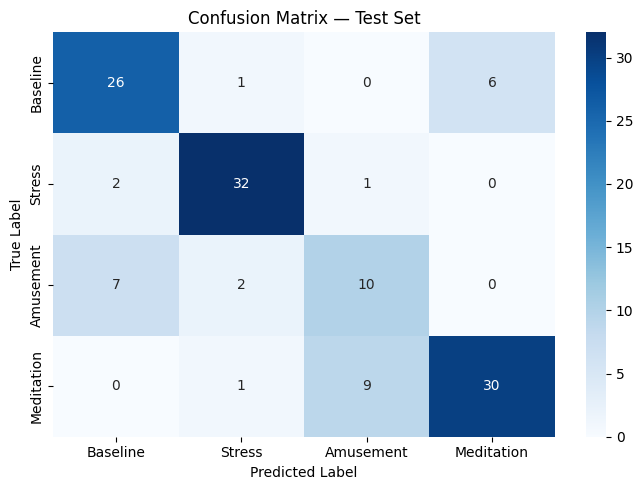

              precision    recall  f1-score   support

    Baseline       0.74      0.79      0.76        33
      Stress       0.89      0.91      0.90        35
   Amusement       0.50      0.53      0.51        19
  Meditation       0.83      0.75      0.79        40

    accuracy                           0.77       127
   macro avg       0.74      0.74      0.74       127
weighted avg       0.78      0.77      0.77       127



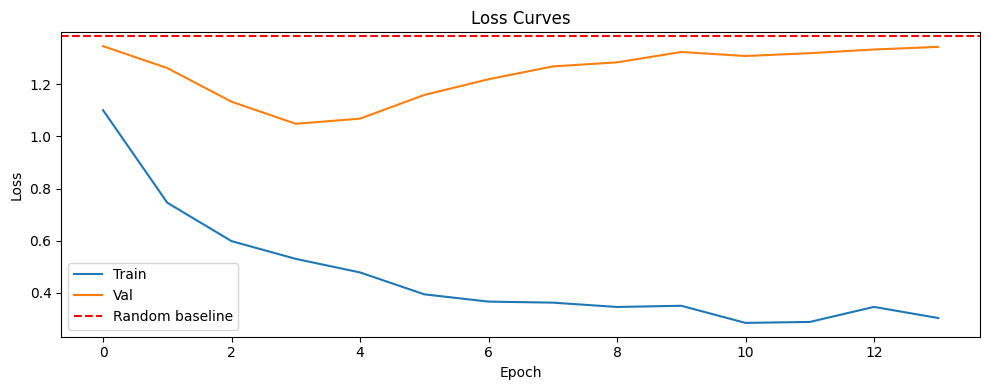

In [ ]:
# ═══════════════════════════════════════════════════
# CELL F — Evaluation
# ═══════════════════════════════════════════════════
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())
        print(f'preds:{preds}')
        print(f'y_batch:{y_batch}')

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
# print(f'y_batch:{all_preds}')
# print(f'all_labels:{all_labels}')
class_names = ['Baseline', 'Stress', 'Amusement', 'Meditation']

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=class_names, zero_division=0))

# Loss curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.axhline(y=np.log(4), color='red', linestyle='--', label='Random baseline')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
unique_labels, counts = np.unique(y_test, return_counts=True)
print(dict(zip(unique_labels, counts)))

{np.int64(1): np.int64(45), np.int64(2): np.int64(35), np.int64(3): np.int64(19), np.int64(4): np.int64(40)}


### Feature Distributions by Label on Test Set

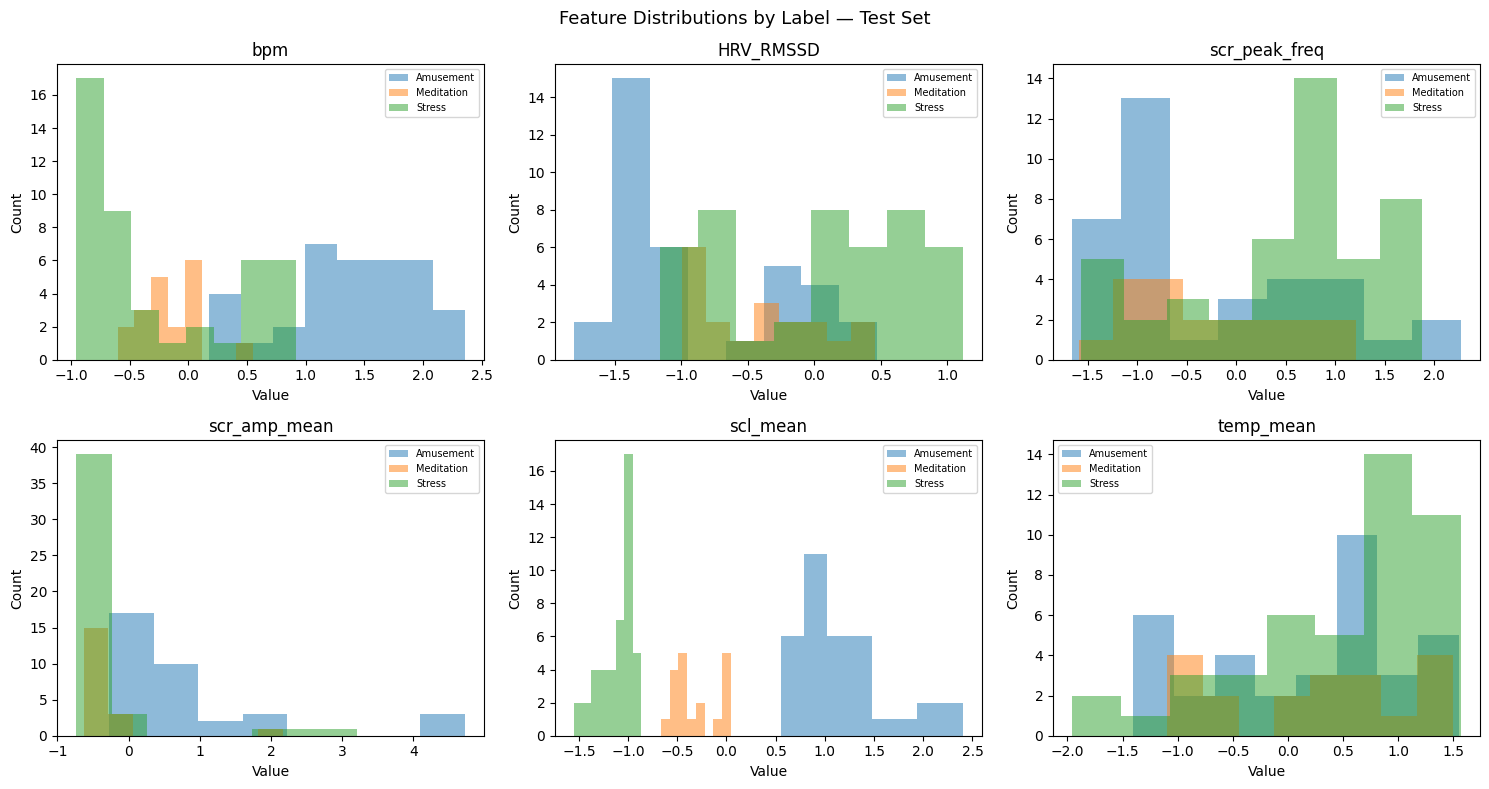

In [ ]:
label_map = {0: 'Baseline', 1: 'Stress', 2: 'Amusement', 3: 'Meditation'}
plot_df   = test_df[test_df['label'].isin([1,2,3,4])].copy() # Original labels are 1-indexed
plot_df['label_name'] = plot_df['label'].map(label_map)

features_to_plot = ['bpm', 'HRV_RMSSD', 'scr_peak_freq',
                    'scr_amp_mean', 'scl_mean', 'temp_mean']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    for label_name, grp in plot_df.groupby('label_name'):
        axes[i].hist(grp[feat], bins=8, alpha=0.5, label=label_name)
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

plt.suptitle('Feature Distributions by Label — Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
def check_accuracy(loader, model, is_train_loader=True):
    if is_train_loader:
        print("Checking accuracy on the training data")
    else:
        print("Checking accuracy on the test data")

    num_correct = 0
    num_samples = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            # Removed .unsqueeze(1) as input is already 3D (batch_size, seq_len, input_size)
            x = x.to(device=device)
            y = y.to(device=device)

            scores = model(x)
            _, predictions = scores.max(1)
            num_correct += (predictions == y).sum()
            num_samples += predictions.size(0)

        print(
            f"Correct examples / total examples = {num_correct} / {num_samples} with accuracy "
            f"{float(num_correct)/float(num_samples)*100:.2f}"
        )

    model.train()

check_accuracy(train_loader, model, is_train_loader=True)
check_accuracy(test_loader, model, is_train_loader=False)

Checking accuracy on the training data
Correct examples / total examples = 374 / 413 with accuracy 90.56
Checking accuracy on the test data
Correct examples / total examples = 98 / 127 with accuracy 77.17
